📋 STEP 1: First 10 Days of Financial Time Series Data
             Gold_Close     BTC_Close
Date                                 
2025-01-01  2606.460570  89543.535434
2025-01-02  2605.301398  89837.446412
2025-01-03  2613.573661  89877.557293
2025-01-04  2632.350019  90019.768611
2025-01-05  2630.040178  89117.156870
2025-01-06  2627.730535  89171.569080
2025-01-07  2647.181089  89794.167029
2025-01-08  2656.890306  91560.539358
2025-01-09  2651.756613  92736.664350
2025-01-10  2658.767333  95345.483299


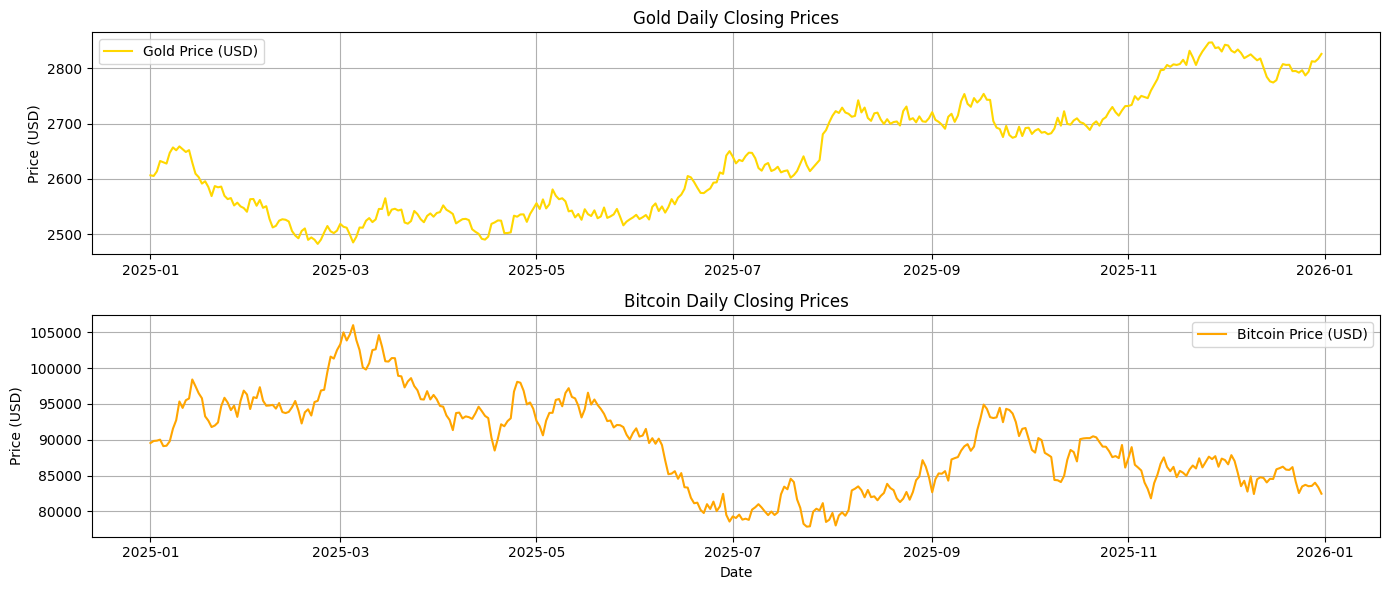

In [1]:
# ==============================================================================
# 📈 STEP 1: Time Series Data Generation for Gold & Bitcoin
# Author: Hasan Wael
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# Generate 365 daily dates
dates = pd.date_range(start='2025-01-01', periods=365, freq='D')

# Simulate daily price trends with drift and random walk volatility
gold_drift = 0.5
gold_volatility = 12.0
gold_returns = np.random.normal(gold_drift, gold_volatility, size=365)
gold_price = 2600 + np.cumsum(gold_returns)  # Base price ~ $2600

btc_drift = 25.0
btc_volatility = 1200.0
btc_returns = np.random.normal(btc_drift, btc_volatility, size=365)
btc_price = 90000 + np.cumsum(btc_returns)   # Base price ~ $90,000

# Create DataFrame
df_financial = pd.DataFrame({
    'Date': dates,
    'Gold_Close': gold_price,
    'BTC_Close': btc_price
}).set_index('Date')

print("======================================================================")
print("📋 STEP 1: First 10 Days of Financial Time Series Data")
print("======================================================================")
print(df_financial.head(10))

# Plot initial price series
plt.figure(figsize=(14, 6))
plt.subplot(2, 1, 1)
plt.plot(df_financial['Gold_Close'], color='gold', label='Gold Price (USD)')
plt.title('Gold Daily Closing Prices')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(df_financial['BTC_Close'], color='orange', label='Bitcoin Price (USD)')
plt.title('Bitcoin Daily Closing Prices')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

🧪 STEP 2.1: Testing Original Gold Price Series
--- ADF Test Results for: Original Gold Price ---
ADF Statistic: -0.1765
p-value:       0.9413
❌ Result: p-value >= 0.05 -> Series is NON-STATIONARY (Has Unit Root).

🧪 STEP 2.2: Testing Differenced Gold Price Series (d=1)
--- ADF Test Results for: Differenced Gold Price (d=1) ---
ADF Statistic: -20.1988
p-value:       0.0000
✅ Result: p-value < 0.05 -> Series is STATIONARY (No Unit Root).



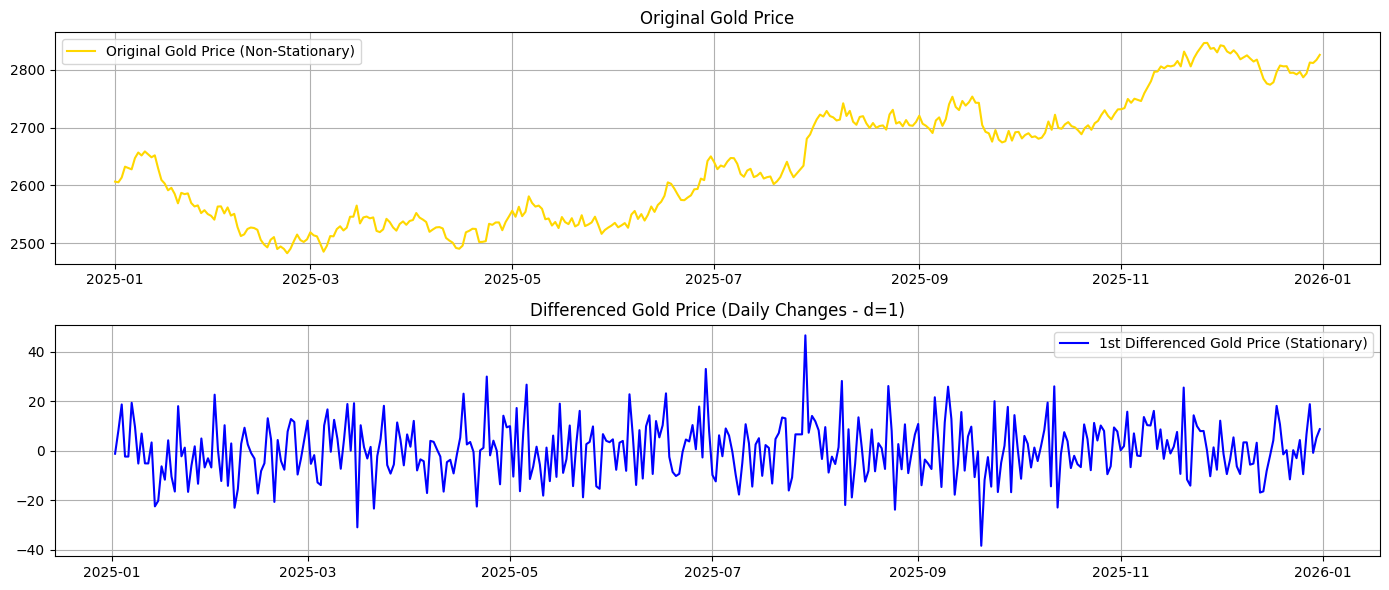

In [2]:
# ==============================================================================
# 🔍 STEP 2: Stationarity Testing (ADF Test) & First-Order Differencing (d=1)
# ==============================================================================

from statsmodels.tsa.stattools import adfuller

def check_adf_stationarity(series, series_name):
    result = adfuller(series.dropna())
    print(f"--- ADF Test Results for: {series_name} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value:       {result[1]:.4f}")
    if result[1] < 0.05:
        print(f"✅ Result: p-value < 0.05 -> Series is STATIONARY (No Unit Root).\n")
    else:
        print(f"❌ Result: p-value >= 0.05 -> Series is NON-STATIONARY (Has Unit Root).\n")

print("======================================================================")
print("🧪 STEP 2.1: Testing Original Gold Price Series")
print("======================================================================")
check_adf_stationarity(df_financial['Gold_Close'], "Original Gold Price")

# Apply First-Order Differencing (d=1)
df_financial['Gold_Diff'] = df_financial['Gold_Close'].diff()

print("======================================================================")
print("🧪 STEP 2.2: Testing Differenced Gold Price Series (d=1)")
print("======================================================================")
check_adf_stationarity(df_financial['Gold_Diff'], "Differenced Gold Price (d=1)")

# Plot Comparison
plt.figure(figsize=(14, 6))
plt.subplot(2, 1, 1)
plt.plot(df_financial['Gold_Close'], color='gold', label='Original Gold Price (Non-Stationary)')
plt.title('Original Gold Price')
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(df_financial['Gold_Diff'], color='blue', label='1st Differenced Gold Price (Stationary)')
plt.title('Differenced Gold Price (Daily Changes - d=1)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

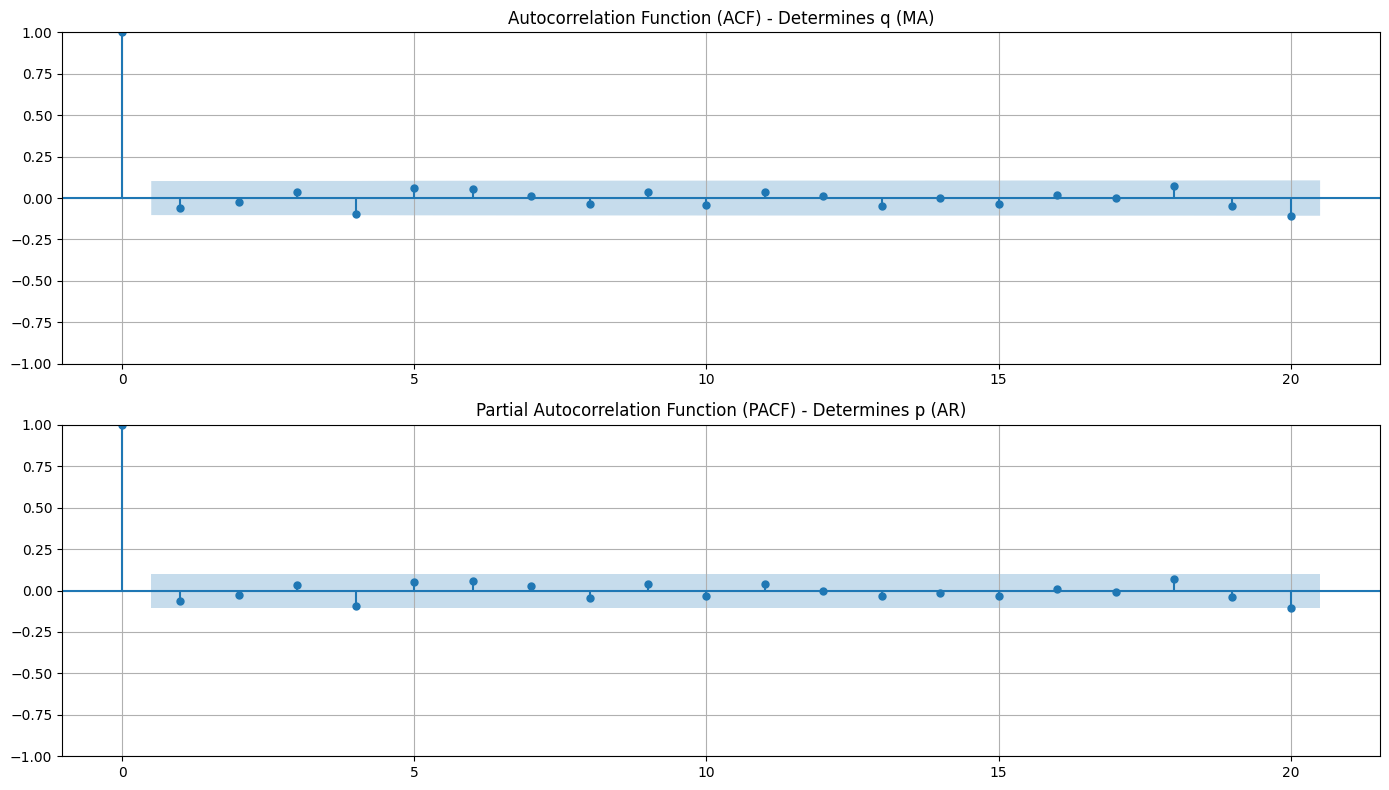

In [3]:
# ==============================================================================
# 📊 STEP 3: Autocorrelation (ACF) & Partial Autocorrelation (PACF) Plots
# ==============================================================================

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# 1. ACF Plot to identify MA(q)
plot_acf(df_financial['Gold_Diff'].dropna(), lags=20, ax=ax1, title='Autocorrelation Function (ACF) - Determines q (MA)')
ax1.grid(True)

# 2. PACF Plot to identify AR(p)
plot_pacf(df_financial['Gold_Diff'].dropna(), lags=20, ax=ax2, title='Partial Autocorrelation Function (PACF) - Determines p (AR)')
ax2.grid(True)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


📋 STEP 4.1: ARIMA Model Summary
                               SARIMAX Results                                
Dep. Variable:             Gold_Close   No. Observations:                  365
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1401.272
Date:                Sat, 25 Jul 2026   AIC                           2808.543
Time:                        02:13:06   BIC                           2820.235
Sample:                    01-01-2025   HQIC                          2813.190
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1950      0.847      0.230      0.818      -1.466       1.856
ma.L1         -0.2553      0.833     -0.307      0.759      -1.888       1.377
sigma2       129.211

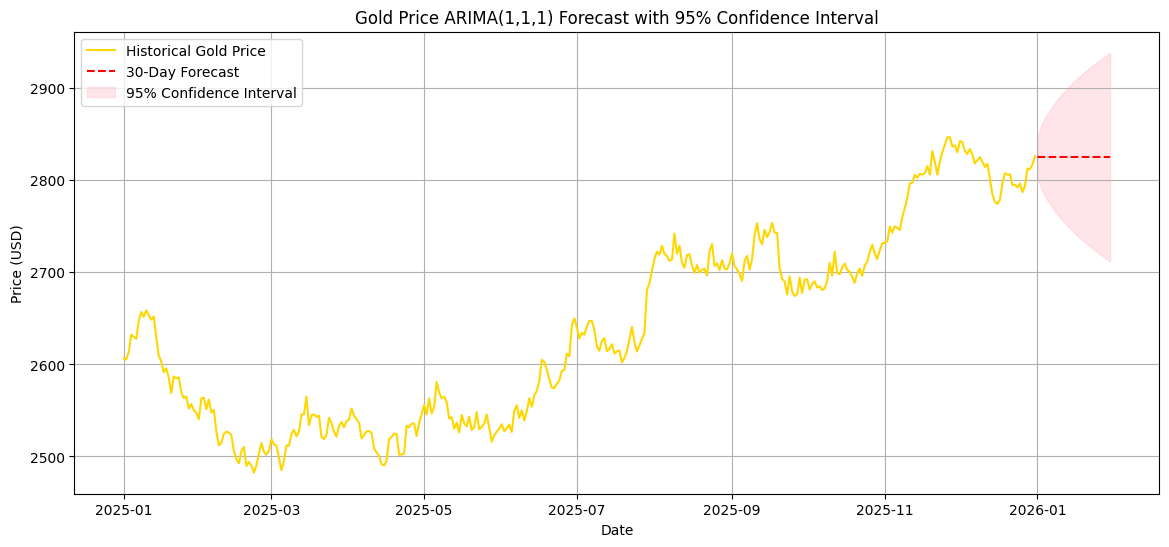

In [4]:
# ==============================================================================
# 🤖 STEP 4: ARIMA Model Training & 30-Day Future Forecasting
# ==============================================================================

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Fit ARIMA(1,1,1) Model on Gold Close Price
arima_model = ARIMA(df_financial['Gold_Close'], order=(1, 1, 1))
arima_result = arima_model.fit()

print("======================================================================")
print("📋 STEP 4.1: ARIMA Model Summary")
print("======================================================================")
print(arima_result.summary())

# 2. Forecast Next 30 Days
forecast_steps = 30
forecast_res = arima_result.get_forecast(steps=forecast_steps)
forecast_df = forecast_res.summary_frame()

# Generate Future Dates
last_date = df_financial.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_steps, freq='D')
forecast_df.index = future_dates

print("\n======================================================================")
print("🔮 STEP 4.2: First 5 Days of 30-Day Future Forecast")
print("======================================================================")
print(forecast_df[['mean', 'mean_ci_lower', 'mean_ci_upper']].head())

# 3. Calculate Historical In-Sample Accuracy Metrics
in_sample_pred = arima_result.predict(start=1, end=len(df_financial)-1)
actual_series = df_financial['Gold_Close'].iloc[1:]

mae = mean_absolute_error(actual_series, in_sample_pred)
rmse = np.sqrt(mean_squared_error(actual_series, in_sample_pred))
mape = np.mean(np.abs((actual_series - in_sample_pred) / actual_series)) * 100

print("\n======================================================================")
print("📊 STEP 4.3: ARIMA Accuracy Metrics")
print("======================================================================")
print(f"Mean Absolute Error (MAE):     ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Mean Absolute % Error (MAPE):   {mape:.2f}%")

# 4. Plot Forecast with Confidence Interval
plt.figure(figsize=(14, 6))
plt.plot(df_financial['Gold_Close'], label='Historical Gold Price', color='gold')
plt.plot(forecast_df['mean'], label='30-Day Forecast', color='red', linestyle='--')
plt.fill_between(forecast_df.index, forecast_df['mean_ci_lower'], forecast_df['mean_ci_upper'], color='pink', alpha=0.4, label='95% Confidence Interval')

plt.title('Gold Price ARIMA(1,1,1) Forecast with 95% Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

📊 STEP 5.1: Comparative Performance Table (ARIMA vs Prophet)
  Metric ARIMA(1,1,1) Meta Prophet
 MAE ($)        $9.00       $10.86
RMSE ($)       $11.37       $13.58
MAPE (%)        0.34%        0.41%


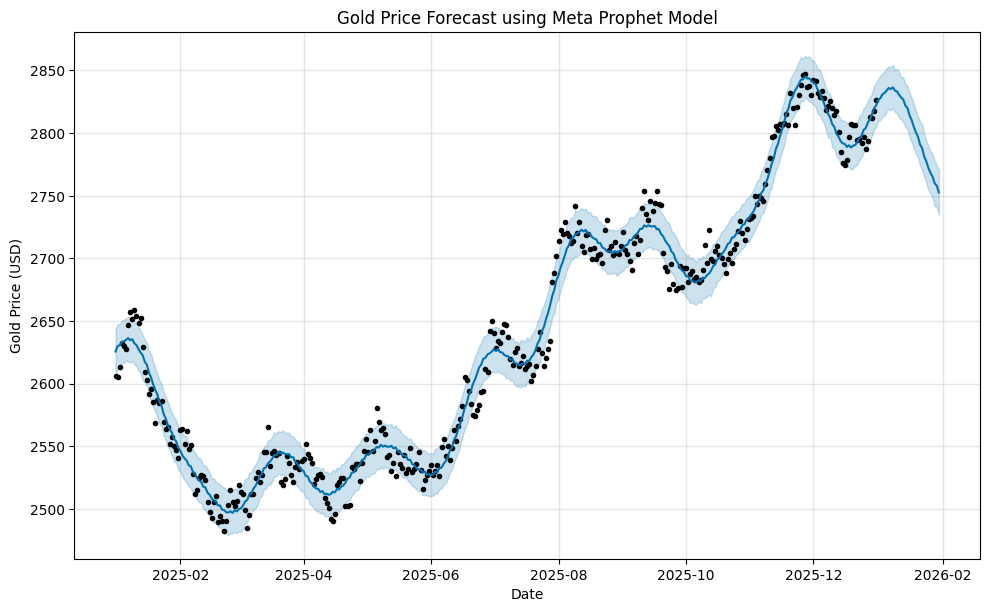

In [5]:
# ==============================================================================
# 🔮 STEP 5: Prophet Model Training & Comparative Performance Analysis
# ==============================================================================

from prophet import Prophet

# 1. Prepare Data for Prophet (Requires 'ds' and 'y' columns)
df_prophet = df_financial.reset_index()[['Date', 'Gold_Close']].rename(columns={'Date': 'ds', 'Gold_Close': 'y'})

# 2. Fit Prophet Model
prophet_model = Prophet(daily_seasonality=True, yearly_seasonality=True, weekly_seasonality=True)
prophet_model.fit(df_prophet)

# 3. Create Future Dataframe for 30 Days
future = prophet_model.make_future_dataframe(periods=30)
forecast_prophet = prophet_model.predict(future)

# 4. In-Sample Prediction for Metrics Calculation
df_in_sample = forecast_prophet.iloc[:len(df_prophet)]

p_mae = mean_absolute_error(df_prophet['y'], df_in_sample['yhat'])
p_rmse = np.sqrt(mean_squared_error(df_prophet['y'], df_in_sample['yhat']))
p_mape = np.mean(np.abs((df_prophet['y'] - df_in_sample['yhat']) / df_prophet['y'])) * 100

print("======================================================================")
print("📊 STEP 5.1: Comparative Performance Table (ARIMA vs Prophet)")
print("======================================================================")
comparison_df = pd.DataFrame({
    'Metric': ['MAE ($)', 'RMSE ($)', 'MAPE (%)'],
    'ARIMA(1,1,1)': [f"${mae:.2f}", f"${rmse:.2f}", f"{mape:.2f}%"],
    'Meta Prophet': [f"${p_mae:.2f}", f"${p_rmse:.2f}", f"{p_mape:.2f}%"]
})
print(comparison_df.to_string(index=False))

# 5. Plot Prophet Forecast
fig1 = prophet_model.plot(forecast_prophet)
plt.title('Gold Price Forecast using Meta Prophet Model')
plt.xlabel('Date')
plt.ylabel('Gold Price (USD)')
plt.show()

In [6]:
# ==============================================================================
# 📤 STEP 6: Consolidate & Export Predictions for Power BI Dashboard
# ==============================================================================

# 1. Historical Actuals Data
df_export_historical = df_financial.reset_index()[['Date', 'Gold_Close', 'BTC_Close']].copy()
df_export_historical.columns = ['Date', 'Gold_Actual', 'BTC_Actual']
df_export_historical['Data_Type'] = 'Historical'
df_export_historical['Gold_ARIMA_Forecast'] = np.nan
df_export_historical['Gold_Prophet_Forecast'] = np.nan
df_export_historical['Gold_CI_Lower'] = np.nan
df_export_historical['Gold_CI_Upper'] = np.nan

# 2. Future Forecast Data (Next 30 Days)
future_dates = forecast_df.index

df_export_future = pd.DataFrame({
    'Date': future_dates,
    'Gold_Actual': np.nan,
    'BTC_Actual': np.nan,
    'Data_Type': 'Forecast',
    'Gold_ARIMA_Forecast': forecast_df['mean'].values,
    'Gold_Prophet_Forecast': forecast_prophet.iloc[-30:]['yhat'].values,
    'Gold_CI_Lower': forecast_df['mean_ci_lower'].values,
    'Gold_CI_Upper': forecast_df['mean_ci_upper'].values
})

# 3. Concatenate and Export
df_final_powerbi = pd.concat([df_export_historical, df_export_future], ignore_index=True)
df_final_powerbi.to_csv('Gold_BTC_Time_Series_Forecast_PowerBI.csv', index=False)

print("======================================================================")
print("✅ STEP 6: Dataset Exported Successfully!")
print("======================================================================")
print("File Name: 'Gold_BTC_Time_Series_Forecast_PowerBI.csv'")
print(f"Total Rows Exported: {len(df_final_powerbi)} (Historical: {len(df_export_historical)} + Forecast: 30)")
print("\nFirst 5 Rows of Exported Data:")
print(df_final_powerbi.head())

✅ STEP 6: Dataset Exported Successfully!
File Name: 'Gold_BTC_Time_Series_Forecast_PowerBI.csv'
Total Rows Exported: 395 (Historical: 365 + Forecast: 30)

First 5 Rows of Exported Data:
        Date  Gold_Actual    BTC_Actual   Data_Type  Gold_ARIMA_Forecast  \
0 2025-01-01  2606.460570  89543.535434  Historical                  NaN   
1 2025-01-02  2605.301398  89837.446412  Historical                  NaN   
2 2025-01-03  2613.573661  89877.557293  Historical                  NaN   
3 2025-01-04  2632.350019  90019.768611  Historical                  NaN   
4 2025-01-05  2630.040178  89117.156870  Historical                  NaN   

   Gold_Prophet_Forecast  Gold_CI_Lower  Gold_CI_Upper  
0                    NaN            NaN            NaN  
1                    NaN            NaN            NaN  
2                    NaN            NaN            NaN  
3                    NaN            NaN            NaN  
4                    NaN            NaN            NaN  
